In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [2]:
# 读取Excel文件中的数据
file_path = 'D:/creep rupture/TL/温度分类/重选特征/目标TSdata800-900.xlsx'
data = pd.read_excel(file_path)

# 归一化数据
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data.values)

In [3]:
# 定义生成器模型
def build_generator(latent_dim, output_dim):
    model = Sequential()
    model.add(Dense(128, input_dim=latent_dim))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(output_dim, activation='sigmoid'))
    return model

# 定义判别器模型
def build_discriminator(input_dim):
    model = Sequential()
    model.add(Dense(512, input_dim=input_dim))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(0.4))
    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(0.4))
    model.add(Dense(1024))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))
    return model

# 定义CGAN模型
def build_cgan(generator, discriminator, latent_dim):
    discriminator.trainable = False  # 判别器不可训练
    model = Sequential([generator, discriminator])
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0001, beta_1=0.5))
    return model

# 定义外推函数
def extrapolate_data(generator, latent_dim, num_samples):
    input_data = np.random.normal(0, 1, size=(num_samples, latent_dim))
    extrapolated_data = generator.predict(input_data)
    return extrapolated_data

# 定义训练函数
def train_cgan(generator, discriminator, cgan, scaled_data, epochs, batch_size, latent_dim):
    discriminator.trainable = True
    discriminator.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0001, beta_1=0.5))

    discriminator_loss_history = []
    generator_loss_history = []

    for e in range(epochs):
        discriminator_loss = 0
        generator_loss = 0

        # 训练判别器
        noise = np.random.normal(0, 1, size=(batch_size, latent_dim))
        generated_data = generator.predict(noise)

        real_data_index = np.random.randint(0, scaled_data.shape[0], size=batch_size)
        real_data = scaled_data[real_data_index]

        data_batch = np.concatenate([real_data, generated_data])

        labels_batch_real = np.ones((batch_size, 1)) * 0.9  # 真实样本
        labels_batch_fake = np.zeros((batch_size, 1))  # 假样本
        labels_batch = np.concatenate([labels_batch_real, labels_batch_fake])

        discriminator_loss += discriminator.train_on_batch(data_batch, labels_batch)

        # 训练生成器
        noise = np.random.normal(0, 1, size=(batch_size, latent_dim))
        labels_batch = np.ones((batch_size, 1))
        generator_loss += cgan.train_on_batch(noise, labels_batch)

        discriminator_loss_history.append(discriminator_loss)
        generator_loss_history.append(generator_loss)

        print(f'Epoch {e+1}/{epochs}, Discriminator Loss: {discriminator_loss}, Generator Loss: {generator_loss}')

    # 绘制损失曲线图
    plt.plot(range(epochs), discriminator_loss_history, label='Discriminator Loss')
    plt.plot(range(epochs), generator_loss_history, label='Generator Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    return generator

1/1 [==============================] - 0s 356ms/step
Epoch 1/1000, Discriminator Loss: 0.6970784664154053, Generator Loss: 0.6915619373321533
1/1 [==============================] - 0s 41ms/step
Epoch 2/1000, Discriminator Loss: 0.6940484046936035, Generator Loss: 0.7250819206237793
1/1 [==============================] - 0s 46ms/step
Epoch 3/1000, Discriminator Loss: 0.6876484155654907, Generator Loss: 0.745331883430481
1/1 [==============================] - 0s 65ms/step
Epoch 4/1000, Discriminator Loss: 0.6843539476394653, Generator Loss: 0.7322916984558105
1/1 [==============================] - 0s 50ms/step
Epoch 5/1000, Discriminator Loss: 0.6827694773674011, Generator Loss: 0.7586398720741272
1/1 [==============================] - 0s 45ms/step
Epoch 6/1000, Discriminator Loss: 0.6716135740280151, Generator Loss: 0.7745757102966309
1/1 [==============================] - 0s 48ms/step
Epoch 7/1000, Discriminator Loss: 0.6697090864181519, Generator Loss: 0.7827637195587158
1/1 [========

1/1 [==============================] - 0s 46ms/step
Epoch 59/1000, Discriminator Loss: 0.5583709478378296, Generator Loss: 1.1818349361419678
1/1 [==============================] - 0s 44ms/step
Epoch 60/1000, Discriminator Loss: 0.6075810790061951, Generator Loss: 1.1171565055847168
1/1 [==============================] - 0s 43ms/step
Epoch 61/1000, Discriminator Loss: 0.5645304918289185, Generator Loss: 1.190443992614746
1/1 [==============================] - 0s 40ms/step
Epoch 62/1000, Discriminator Loss: 0.5387951135635376, Generator Loss: 1.1784093379974365
1/1 [==============================] - 0s 44ms/step
Epoch 63/1000, Discriminator Loss: 0.5452944040298462, Generator Loss: 1.1754088401794434
1/1 [==============================] - 0s 60ms/step
Epoch 64/1000, Discriminator Loss: 0.5138897895812988, Generator Loss: 1.2341861724853516
1/1 [==============================] - 0s 43ms/step
Epoch 65/1000, Discriminator Loss: 0.5503317713737488, Generator Loss: 1.1678698062896729
1/1 [==

1/1 [==============================] - 0s 43ms/step
Epoch 117/1000, Discriminator Loss: 0.465970903635025, Generator Loss: 1.4979157447814941
1/1 [==============================] - 0s 43ms/step
Epoch 118/1000, Discriminator Loss: 0.5055318474769592, Generator Loss: 1.521773338317871
1/1 [==============================] - 0s 44ms/step
Epoch 119/1000, Discriminator Loss: 0.501192569732666, Generator Loss: 1.404155969619751
1/1 [==============================] - 0s 44ms/step
Epoch 120/1000, Discriminator Loss: 0.4983136057853699, Generator Loss: 1.5556226968765259
1/1 [==============================] - 0s 41ms/step
Epoch 121/1000, Discriminator Loss: 0.5018894672393799, Generator Loss: 1.4687711000442505
1/1 [==============================] - 0s 46ms/step
Epoch 122/1000, Discriminator Loss: 0.49788400530815125, Generator Loss: 1.5315905809402466
1/1 [==============================] - 0s 45ms/step
Epoch 123/1000, Discriminator Loss: 0.5081700682640076, Generator Loss: 1.4736698865890503
1/

1/1 [==============================] - 0s 43ms/step
Epoch 175/1000, Discriminator Loss: 0.4748922884464264, Generator Loss: 1.6291007995605469
1/1 [==============================] - 0s 45ms/step
Epoch 176/1000, Discriminator Loss: 0.49046480655670166, Generator Loss: 1.6112825870513916
1/1 [==============================] - 0s 45ms/step
Epoch 177/1000, Discriminator Loss: 0.39140957593917847, Generator Loss: 1.7421618700027466
1/1 [==============================] - 0s 45ms/step
Epoch 178/1000, Discriminator Loss: 0.4572865068912506, Generator Loss: 1.5531623363494873
1/1 [==============================] - 0s 45ms/step
Epoch 179/1000, Discriminator Loss: 0.5910437107086182, Generator Loss: 1.645909309387207
1/1 [==============================] - 0s 40ms/step
Epoch 180/1000, Discriminator Loss: 0.43980082869529724, Generator Loss: 1.766661524772644
1/1 [==============================] - 0s 52ms/step
Epoch 181/1000, Discriminator Loss: 0.5015407800674438, Generator Loss: 1.557991266250610

1/1 [==============================] - 0s 46ms/step
Epoch 232/1000, Discriminator Loss: 0.5264725685119629, Generator Loss: 1.4617087841033936
1/1 [==============================] - 0s 48ms/step
Epoch 233/1000, Discriminator Loss: 0.424698144197464, Generator Loss: 1.404517412185669
1/1 [==============================] - 0s 44ms/step
Epoch 234/1000, Discriminator Loss: 0.4606211185455322, Generator Loss: 1.7459663152694702
1/1 [==============================] - 0s 46ms/step
Epoch 235/1000, Discriminator Loss: 0.5749830007553101, Generator Loss: 1.6464989185333252
1/1 [==============================] - 0s 45ms/step
Epoch 236/1000, Discriminator Loss: 0.5531871318817139, Generator Loss: 1.5556095838546753
1/1 [==============================] - 0s 44ms/step
Epoch 237/1000, Discriminator Loss: 0.48912370204925537, Generator Loss: 1.3583868741989136
1/1 [==============================] - 0s 43ms/step
Epoch 238/1000, Discriminator Loss: 0.5013021230697632, Generator Loss: 1.896100640296936
1

...

1/1 [==============================] - 0s 42ms/step
Epoch 754/1000, Discriminator Loss: 0.5745174288749695, Generator Loss: 0.9621154069900513
1/1 [==============================] - 0s 38ms/step
Epoch 755/1000, Discriminator Loss: 0.534376859664917, Generator Loss: 1.1533114910125732
1/1 [==============================] - 0s 44ms/step
Epoch 756/1000, Discriminator Loss: 0.5714393854141235, Generator Loss: 1.0860486030578613
1/1 [==============================] - 0s 44ms/step
Epoch 757/1000, Discriminator Loss: 0.5624985694885254, Generator Loss: 1.1715507507324219
1/1 [==============================] - 0s 56ms/step
Epoch 758/1000, Discriminator Loss: 0.5663783550262451, Generator Loss: 1.3138327598571777
1/1 [==============================] - 0s 56ms/step
Epoch 759/1000, Discriminator Loss: 0.6201310753822327, Generator Loss: 1.178082823753357
1/1 [==============================] - 0s 46ms/step
Epoch 760/1000, Discriminator Loss: 0.5123474597930908, Generator Loss: 1.1269816160202026
1

1/1 [==============================] - 0s 45ms/step
Epoch 812/1000, Discriminator Loss: 0.5616907477378845, Generator Loss: 1.1136586666107178
1/1 [==============================] - 0s 50ms/step
Epoch 813/1000, Discriminator Loss: 0.5836860537528992, Generator Loss: 1.0942745208740234
1/1 [==============================] - 0s 43ms/step
Epoch 814/1000, Discriminator Loss: 0.5561317205429077, Generator Loss: 1.1672841310501099
1/1 [==============================] - 0s 46ms/step
Epoch 815/1000, Discriminator Loss: 0.49730414152145386, Generator Loss: 1.1411161422729492
1/1 [==============================] - 0s 43ms/step
Epoch 816/1000, Discriminator Loss: 0.5587046146392822, Generator Loss: 1.2566092014312744
1/1 [==============================] - 0s 51ms/step
Epoch 817/1000, Discriminator Loss: 0.6220450401306152, Generator Loss: 1.1545610427856445
1/1 [==============================] - 0s 43ms/step
Epoch 818/1000, Discriminator Loss: 0.5629829168319702, Generator Loss: 1.031533718109130

1/1 [==============================] - 0s 48ms/step
Epoch 870/1000, Discriminator Loss: 0.5832391381263733, Generator Loss: 1.2428627014160156
1/1 [==============================] - 0s 42ms/step
Epoch 871/1000, Discriminator Loss: 0.5538777112960815, Generator Loss: 1.24507737159729
1/1 [==============================] - 0s 44ms/step
Epoch 872/1000, Discriminator Loss: 0.5146973133087158, Generator Loss: 1.1503452062606812
1/1 [==============================] - 0s 45ms/step
Epoch 873/1000, Discriminator Loss: 0.5751945972442627, Generator Loss: 1.1768836975097656
1/1 [==============================] - 0s 50ms/step
Epoch 874/1000, Discriminator Loss: 0.5401954650878906, Generator Loss: 1.1898895502090454
1/1 [==============================] - 0s 42ms/step
Epoch 875/1000, Discriminator Loss: 0.5439934134483337, Generator Loss: 1.333491563796997
1/1 [==============================] - 0s 42ms/step
Epoch 876/1000, Discriminator Loss: 0.5301434993743896, Generator Loss: 1.2804234027862549
1/

1/1 [==============================] - 0s 45ms/step
Epoch 928/1000, Discriminator Loss: 0.5438385605812073, Generator Loss: 1.4833908081054688
1/1 [==============================] - 0s 42ms/step
Epoch 929/1000, Discriminator Loss: 0.5218620300292969, Generator Loss: 1.167331337928772
1/1 [==============================] - 0s 45ms/step
Epoch 930/1000, Discriminator Loss: 0.603463888168335, Generator Loss: 1.1841552257537842
1/1 [==============================] - 0s 44ms/step
Epoch 931/1000, Discriminator Loss: 0.5270465612411499, Generator Loss: 1.2906111478805542
1/1 [==============================] - 0s 43ms/step
Epoch 932/1000, Discriminator Loss: 0.5543005466461182, Generator Loss: 1.333970069885254
1/1 [==============================] - 0s 42ms/step
Epoch 933/1000, Discriminator Loss: 0.5528883934020996, Generator Loss: 1.2681893110275269
1/1 [==============================] - 0s 44ms/step
Epoch 934/1000, Discriminator Loss: 0.45951780676841736, Generator Loss: 1.2039445638656616
1

1/1 [==============================] - 0s 44ms/step
Epoch 986/1000, Discriminator Loss: 0.4996490478515625, Generator Loss: 1.2193806171417236
1/1 [==============================] - 0s 62ms/step
Epoch 987/1000, Discriminator Loss: 0.498617947101593, Generator Loss: 1.322496771812439
1/1 [==============================] - 0s 41ms/step
Epoch 988/1000, Discriminator Loss: 0.5075516700744629, Generator Loss: 1.3832387924194336
1/1 [==============================] - 0s 45ms/step
Epoch 989/1000, Discriminator Loss: 0.5058256983757019, Generator Loss: 1.0620158910751343
1/1 [==============================] - 0s 45ms/step
Epoch 990/1000, Discriminator Loss: 0.550552248954773, Generator Loss: 1.3678655624389648
1/1 [==============================] - 0s 45ms/step
Epoch 991/1000, Discriminator Loss: 0.49643996357917786, Generator Loss: 1.3284990787506104
1/1 [==============================] - 0s 55ms/step
Epoch 992/1000, Discriminator Loss: 0.5835123658180237, Generator Loss: 1.053000807762146
1/

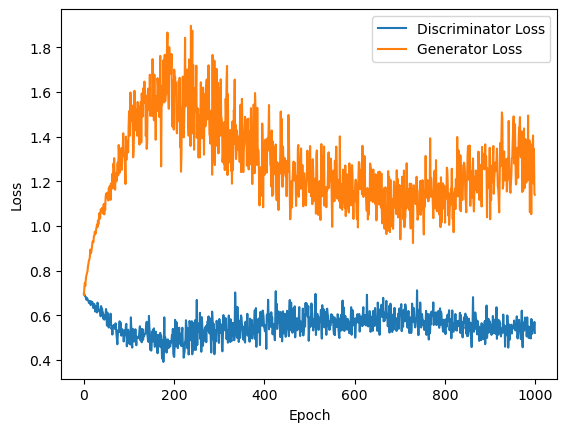

1/1 [==============================] - 0s 248ms/step
外推数据已保存到: D:/creep rupture/TL/温度分类/重选特征/消融实验800-900.xlsx


In [4]:
# 参数设置
latent_dim = 100  # 噪声维度
output_dim = scaled_data.shape[1]  # 输出维度
input_dim = output_dim  # 输入维度
epochs = 1000  # 训练轮数
batch_size = 32  # 批量大小

# 构建生成器和判别器
generator = build_generator(latent_dim, output_dim)
discriminator = build_discriminator(input_dim)

# 构建CGAN模型
cgan = build_cgan(generator, discriminator, latent_dim)

# 训练CGAN模型
trained_generator = train_cgan(generator, discriminator, cgan, scaled_data, epochs, batch_size, latent_dim)

# 外推数据
num_generated_samples = 20  # 生成样本数量
extrapolated_data = extrapolate_data(trained_generator, latent_dim, num_generated_samples)

# 反归一化数据
extrapolated_data = scaler.inverse_transform(extrapolated_data)

# 筛选上四分位数抗拉强度数据
tensile_strength_column = 'Tensile Strength(Mpa)'  # 假设抗拉强度列名
tensile_strength_values = extrapolated_data[:, data.columns.get_loc(tensile_strength_column)]
upper_quartile_threshold = np.percentile(tensile_strength_values, 75)
filtered_extrapolated_data = extrapolated_data[tensile_strength_values > upper_quartile_threshold]

# 保存外推数据到Excel文件
extrapolated_df = pd.DataFrame(filtered_extrapolated_data, columns=data.columns)
output_file_path = 'D:/creep rupture/TL/温度分类/重选特征/消融实验800-900.xlsx'
extrapolated_df.to_excel(output_file_path, index=False)
print("外推数据已保存到:", output_file_path)